In [ ]:
import numpy as np
# 读取数据时，请注意tsv文件的实际存储位置
data = np.genfromtxt(r'D:\gwzMLCode\web_traffic.tsv',delimiter="\t")

#print(data[:10])
#print(data.shape)

In [5]:
# 向量x包含小时信息，向量y包含某个小时内的Web访问数
x = data[:,0]
y = data[:,1]
#print(x)
#print(y)

In [6]:
# 找出y中包含无效值nan的元素
np.sum(np.isnan(y))  # 743个项中只有8个值缺失了，因此把它们删除可以接受
#print(np)

np.int64(8)

In [7]:
# 使用~在逻辑上对数组取反，可在x和y中只选择y值合法的项
x = x[~np.isnan(y)]
y = y[~np.isnan(y)]
#print(x,y)

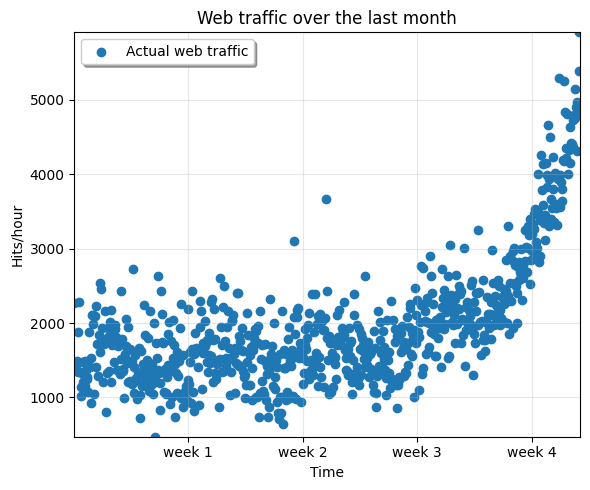

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

# 散点图：实际数据
plt.scatter(x, y, label="Actual web traffic")

# 绘制坐标系
plt.title("Web traffic over the last month")
plt.xlabel("Time")
plt.ylabel("Hits/hour")
plt.xticks([w*7*24 for w in range(10)], ['week %i'%w for w in range(10)])
plt.autoscale(tight=True)
plt.grid(alpha=0.3)

# 改进的图例
plt.legend(
    loc="upper left", 
    frameon=True, 
    fancybox=True, 
    shadow=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

In [9]:
# 定义一个计算误差的函数，用于曲线拟合或回归分析。
# 计算模型预测值与实际观测值之间的平方误差和
# f: 模型函数：x: 自变量（输入特征），y: 因变量（实际观测值）
def error(f, x, y):
    return np.sum((f(x)-y)**2)

In [10]:
# polyfit()对数据点(x,y)进行多项式拟合，并获取详细的拟合结果
# x: 自变量数据, y: 因变量数据, 1: 多项式阶数（1表示线性拟合）,full=True: 返回完整的拟合信息
# fp1: 拟合多项式系数, 对于1次多项式：[斜率, 截距], 拟合直线方程：y = fp1[0]*x + fp1[1]
# residuals: 拟合的残差平方和：sum((y - 拟合值)^2), 用于衡量拟合质量
# rank - 系数矩阵的秩, 表示线性无关的参数数量
# sv - 奇异值, 用于数值稳定性分析
# rcond - 条件数的倒数, 用于判断拟合的数值稳定性
fp1, residuals, rank, sv, rcond = np.polyfit(x, y, 1, full=True)

In [11]:
#【打印线性拟合的模型参数、残差信息】
# 先输出模型参数（拟合系数），fp1 是一个包含两个元素的数组：[斜率, 截距]
# %s 表示这里要插入一个字符串， 第2个%表示将值转换为字符串格式
print("Model parameters: %s" % fp1)  
# 再输出残差平方和，可用于比较不同模型的拟合效果。其值越小，说明该模型的拟合效果越好。
print(residuals)

Model parameters: [  2.59619213 989.02487106]
[3.17389767e+08]


In [12]:
# 使用拟合得到的参数创建一次多项式函数对象，并计算拟合误差。
# fp1是之前polyfit返回的系数数组（[斜率, 截距]），np.poly1d() 将这些系数转换为可调用的函数
f1 = np.poly1d(fp1)
# 以数学形式显示一次多项式方程
print(f1)
# 计算并输出拟合误差，使用之前定义的error函数计算残差平方和
print(error(f1, x, y))

 
2.596 x + 989
317389767.339778


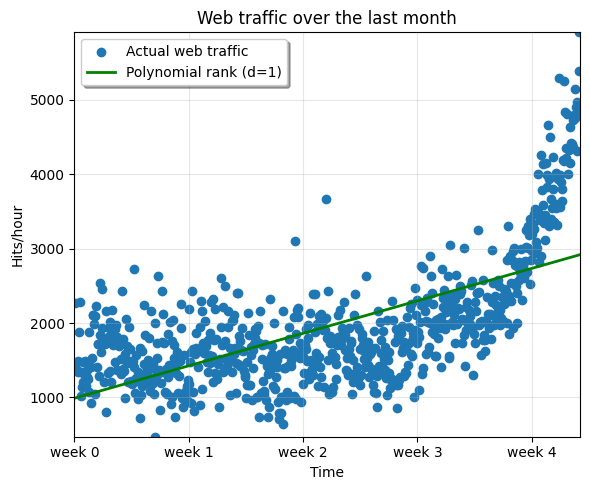

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

# 散点图：实际数据
plt.scatter(x, y, label="Actual web traffic")

# 绘制坐标系
plt.title("Web traffic over the last month")
plt.xlabel("Time")
plt.ylabel("Hits/hour")
plt.xticks([w*7*24 for w in range(10)], ['week %i'%w for w in range(10)])
plt.autoscale(tight=True)
plt.grid(alpha=0.3)
# 直线图：拟合模型
fx = np.linspace(0, x[-1], 1000)
plt.plot(fx, f1(fx), linewidth=2, color="Green", label=f"Polynomial rank (d={f1.order})")

# 改进的图例
plt.legend(
    loc="upper left", 
    frameon=True, 
    fancybox=True, 
    shadow=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

In [14]:
# 进行二次多项式拟合，并计算拟合误差。
# 参数 2 表示使用二次多项式（抛物线）
# 返回系数数组 [a, b, c]，对应方程：y = ax² + bx + c
f2p = np.polyfit(x, y, 2)
# 显示二次多项式的三个系数
print(f2p)

# 创建二次多项式函数对象
f2 = np.poly1d(f2p)
# 以数学形式显示二次多项式方程
print(f2)
# 计算并输出拟合误差
# 当二次拟合误差明显小于一次线性拟合误差时，说明数据确实存在曲线趋势。
print(error(f2, x, y))

[ 1.05322215e-02 -5.26545650e+00  1.97476082e+03]
         2
0.01053 x - 5.265 x + 1975
179983507.8781792


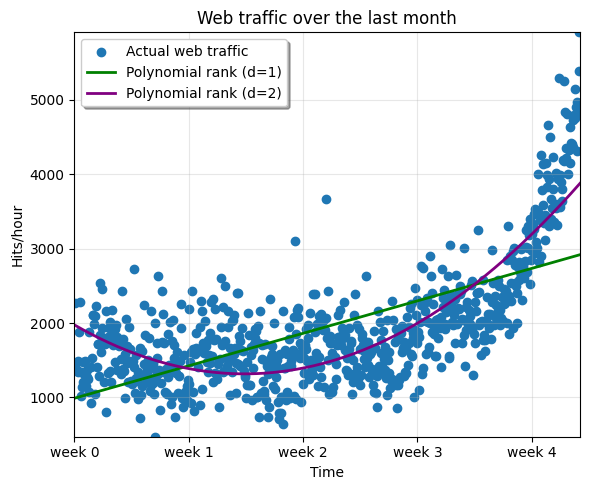

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 5))

# 散点图：实际数据
# plt.scatter(x,y)
plt.scatter(x, y, label="Actual web traffic")
# plt.scatter(x, y, alpha=0.6, label="Actual web traffic", color="blue")

plt.title("Web traffic over the last month")
plt.xlabel("Time")
plt.ylabel("Hits/hour")
plt.xticks([w*7*24 for w in range(10)], ['week %i'%w for w in range(10)])
plt.autoscale(tight=True)
plt.grid(alpha=0.3)

# 直线图：拟合模型
fx = np.linspace(0, x[-1], 1000)
plt.plot(fx, f1(fx), linewidth=2, color="Green", label=f"Polynomial rank (d={f1.order})")
# 二阶曲线图：拟合模型
plt.plot(fx, f2(fx), linewidth=2, color="Purple", label=f"Polynomial rank (d={f2.order})")

# 改进的图例
plt.legend(
    loc="upper left", 
    frameon=True, 
    fancybox=True, 
    shadow=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

In [37]:
f5p = np.polyfit(x, y, 5)
print(f5p)

f5 = np.poly1d(f5p)
print(f5)
print(error(f5, x, y))

[ 2.16470951e-10 -3.13405153e-07  1.63844797e-04 -3.41497485e-02
  2.24785575e+00  1.53616050e+03]
           5             4             3           2
2.165e-10 x - 3.134e-07 x + 0.0001638 x - 0.03415 x + 2.248 x + 1536
124464714.56616358


In [38]:
f10p = np.polyfit(x, y, 10)
print(f10p)

f10 = np.poly1d(f10p)
print(f10)
print(error(f10, x, y))

[-3.73981968e-22  1.36473756e-18 -2.14294406e-15  1.89884971e-12
 -1.04570108e-09  3.70867731e-07 -8.45604588e-05  1.19167041e-02
 -9.41618606e-01  3.33703840e+01  1.26421204e+03]
           10             9             8             7             6
-3.74e-22 x  + 1.365e-18 x - 2.143e-15 x + 1.899e-12 x - 1.046e-09 x
              5             4           3          2
 + 3.709e-07 x - 8.456e-05 x + 0.01192 x - 0.9416 x + 33.37 x + 1264
121942326.36364017


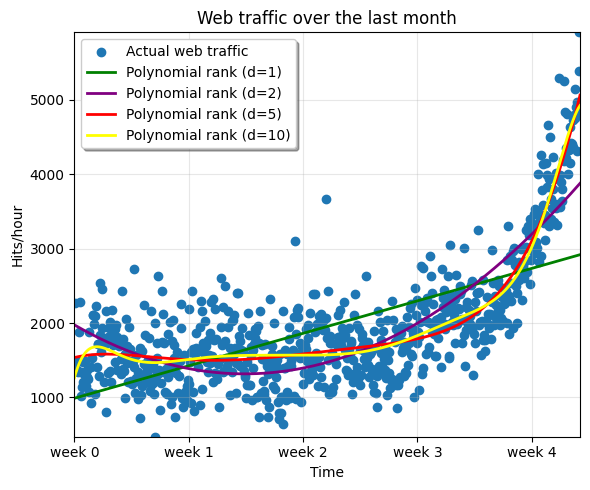

In [39]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 5))

# 散点图：实际数据
# plt.scatter(x,y)
plt.scatter(x, y,label="Actual web traffic")

plt.title("Web traffic over the last month")
plt.xlabel("Time")
plt.ylabel("Hits/hour")
plt.xticks([w*7*24 for w in range(10)], ['week %i'%w for w in range(10)])
plt.autoscale(tight=True)
plt.grid(alpha=0.3)

# 直线图：拟合模型
fx = np.linspace(0, x[-1], 1000)
plt.plot(fx, f1(fx), linewidth=2, color="Green", label=f"Polynomial rank (d={f1.order})")
# 2阶曲线图：拟合模型
plt.plot(fx, f2(fx), linewidth=2, color="Purple", label=f"Polynomial rank (d={f2.order})")
# 5阶曲线图：拟合模型
plt.plot(fx, f5(fx), linewidth=2, color="Red", label=f"Polynomial rank (d={f5.order})")
# 10阶曲线图：拟合模型
plt.plot(fx, f10(fx), linewidth=2, color="Yellow", label=f"Polynomial rank (d={f10.order})")

# 改进的图例
plt.legend(
    loc="upper left", 
    frameon=True, 
    fancybox=True, 
    shadow=True,
    fontsize=10
)

plt.tight_layout()
plt.show()